Saving ImagenTest_GEarh_LR01.png to ImagenTest_GEarh_LR01.png


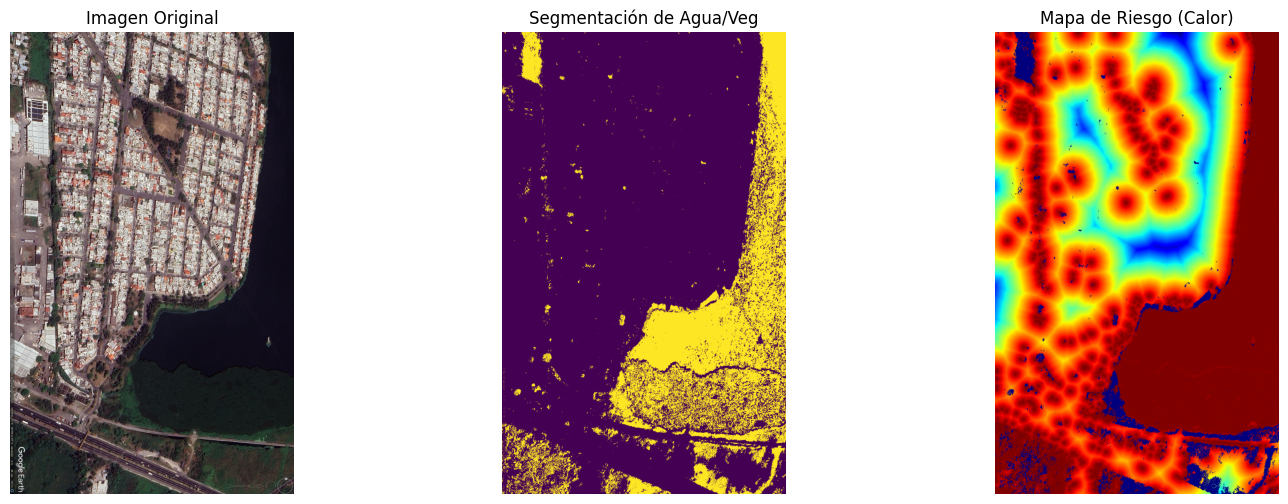

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# 1. CARGA DE IMAGEN
# Sube el archivo 'ImagenTest_GEarh_LR01.png' cuando se te solicite
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

def analyze_flood_risk(path):
    # Leer y convertir a RGB
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- TAREA 1: ADQUISICIÓN Y PREPROCESAMIENTO ---
    # Convertir a escala de grises y aplicar filtro Gaussiano para reducir ruido
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # --- TAREA 2: SEGMENTACIÓN SEMÁNTICA (Heurística) ---
    # En este ejemplo usamos espacios de color para segmentar agua y vegetación
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Máscara para Agua (tonos oscuros/azules en la laguna)
    lower_water = np.array([90, 50, 20])
    upper_water = np.array([130, 255, 100])
    water_mask = cv2.inRange(hsv, lower_water, upper_water)

    # Máscara para Vegetación (tonos verdes)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    # --- TAREA 3: PROYECCIÓN DE RIESGO ---
    # Simulamos que las zonas bajas están cerca del agua y son de concreto
    # Aplicamos una transformada de distancia desde la laguna
    dist_transform = cv2.distanceTransform(cv2.bitwise_not(water_mask), cv2.DIST_L2, 5)
    normalized_dist = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX)

    # El riesgo aumenta si: está cerca del agua (distancia baja) y NO es vegetación
    flood_risk = 255 - normalized_dist.astype(np.uint8)
    flood_risk = cv2.bitwise_and(flood_risk, cv2.bitwise_not(green_mask))

    # --- VISUALIZACIÓN ---
    titles = ['Imagen Original', 'Segmentación de Agua/Veg', 'Mapa de Riesgo (Calor)']
    images = [img_rgb, green_mask + water_mask, flood_risk]

    plt.figure(figsize=(18, 6))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        if i == 2:
            plt.imshow(images[i], cmap='jet')
        else:
            plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

analyze_flood_risk(img_path)

Por favor, sube la imagen 'ImagenTest_GEarh_LR01.png'


Saving ImagenTest_GEarh_LR01.png to ImagenTest_GEarh_LR01 (1).png


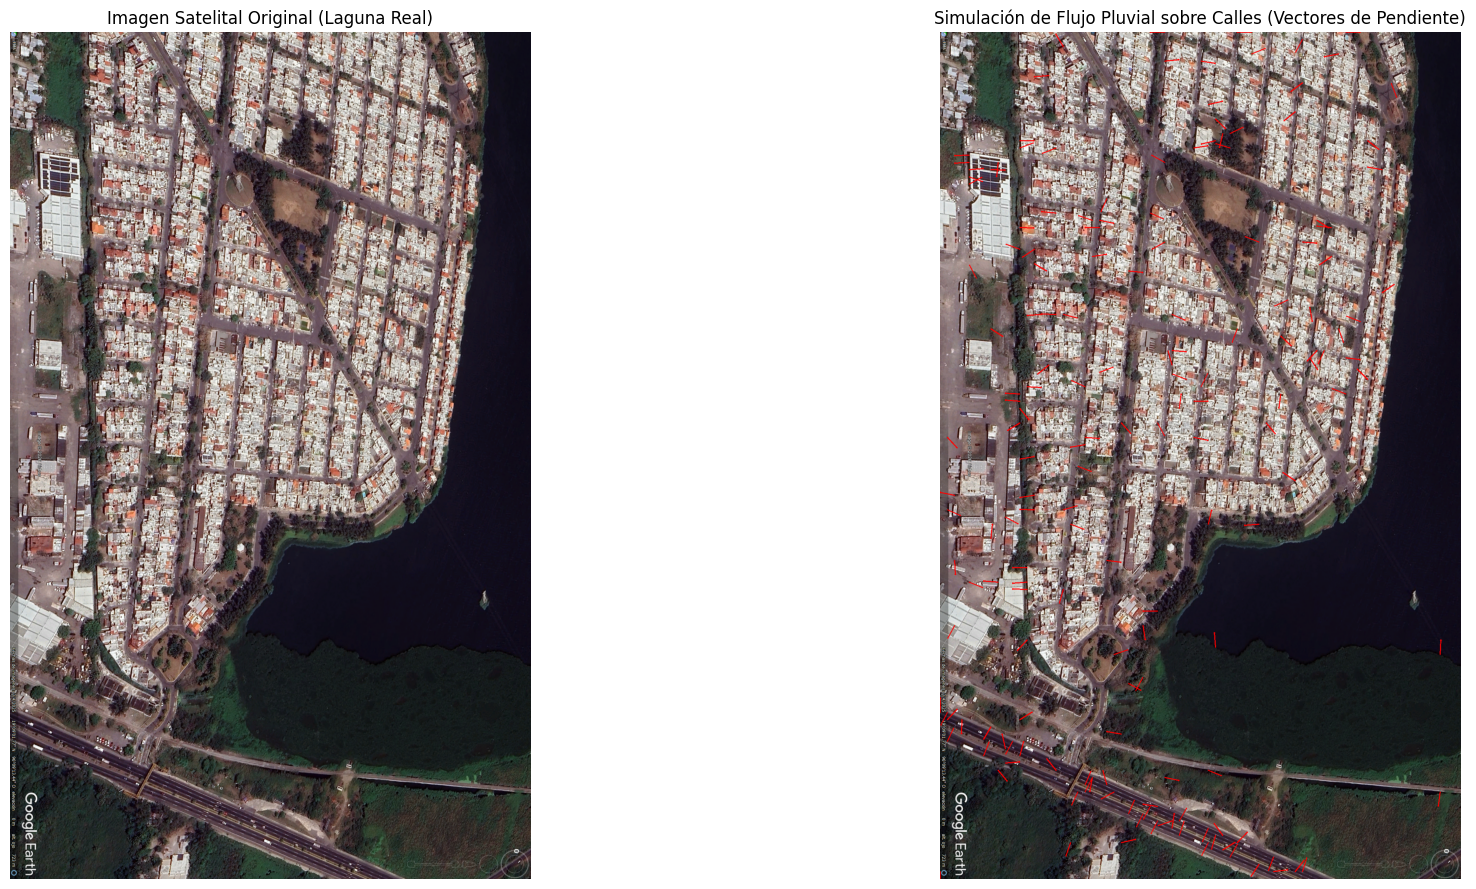

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# ==========================================
# CONFIGURACIÓN EDITABLE DE FLECHAS (FLOW)
# ==========================================
ARROW_COLOR = (0, 0, 255)  # BGR: Rojo Intenso (0,0,255) o Azul (255,0,0)
ARROW_THICKNESS = 2        # Grosor de la línea
ARROW_TIP_SIZE = 1         # Tamaño de la punta de la flecha
GRID_STEP = 20             # Separación entre flechas (más bajo = más denso)
# ==========================================

# 1. CARGA DE IMAGEN (Como en el ejemplo anterior)
print("Por favor, sube la imagen 'ImagenTest_GEarh_LR01.png'")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

def analyze_water_flow(path):
    # Leer y convertir
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- TAREA 2: SEGMENTACIÓN DE CALLES ---
    # Convertir a escala de grises y aplicar CLAHE para resaltar texturas de calles
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray_enhanced = clahe.apply(gray)

    # Detectar calles mediante umbral adaptable (Adaptive Thresholding)
    roads_mask = cv2.adaptiveThreshold(gray_enhanced, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, 11, 2)
    # Limpiar ruido con operaciones morfológicas
    kernel = np.ones((3,3), np.uint8)
    roads_mask = cv2.morphologyEx(roads_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # --- TAREA 3: CÁLCULO DE FLUJO PLUVIAL (Gradiente) ---
    # Usamos Sobel para calcular el gradiente en X e Y
    # El agua fluye EN CONTRA del gradiente (hacia zonas más oscuras o 'bajas')
    sobel_x = cv2.Sobel(gray_enhanced, cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(gray_enhanced, cv2.CV_64F, 0, 1, ksize=5)

    # Calcular ángulo y magnitud (dirección del flujo)
    magnitude, angle = cv2.cartToPolar(sobel_x, sobel_y)

    # Invertir el ángulo para simular flujo hacia abajo (hacia la laguna oscura)
    flow_angle = angle + np.pi

    # --- VISUALIZACIÓN: DIBUJO DE FLECHAS ---
    output_img = img.copy()
    h, w = gray.shape

    # Recorrer la imagen en una cuadrícula (grid)
    for y in range(0, h, GRID_STEP):
        for x in range(0, w, GRID_STEP):
            # Solo dibujar flechas sobre las zonas identificadas como calles
            if roads_mask[y, x] > 0:
                # Obtener la dirección simulada del agua en ese punto
                theta = flow_angle[y, x]

                # Definir longitud de la flecha basada en la magnitud del gradiente
                # (Zonas más empinadas = flechas más largas)
                len_f = int(np.clip(magnitude[y, x] * 1.5, 10, 40))

                # Calcular punto final de la flecha
                x_end = int(x + len_f * np.cos(theta))
                y_end = int(y + len_f * np.sin(theta))

                # Dibujar la flecha
                cv2.arrowedLine(output_img, (x, y), (x_end, y_end),
                                ARROW_COLOR, ARROW_THICKNESS, tipLength=ARROW_TIP_SIZE/len_f)

    # --- VISUALIZACIÓN DE RESULTADOS ---
    final_img_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(22, 11))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagen Satelital Original (Laguna Real)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_img_rgb)
    plt.title('Simulación de Flujo Pluvial sobre Calles (Vectores de Pendiente)')
    plt.axis('off')

    plt.show()

analyze_water_flow(img_path)

Sube la imagen de Laguna Real:


Saving ImagenTest_GEarh01.png to ImagenTest_GEarh01.png


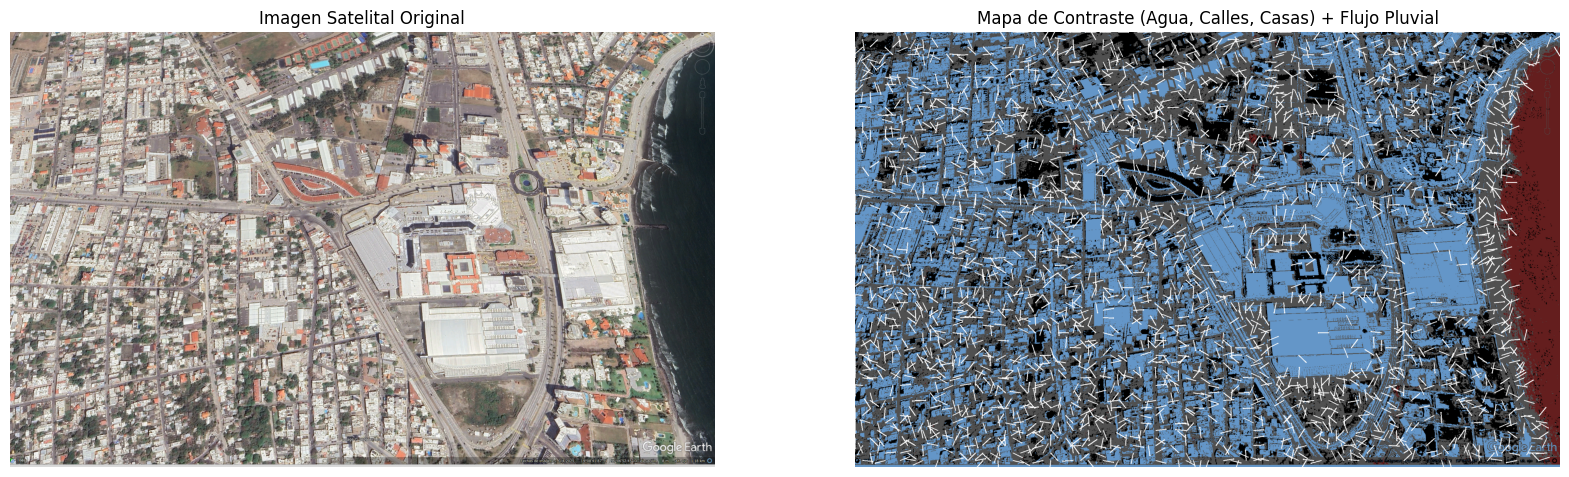

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================
# CONFIGURACIÓN EDITABLE DE FLECHAS (FLOW)
# ==========================================
ARROW_COLOR = (255, 255, 255)  # Blanco para resaltar sobre los contrastes
ARROW_THICKNESS = 2
ARROW_TIP_SIZE = 1
GRID_STEP = 25
# ==========================================

print("Sube la imagen de Laguna Real:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

def analyze_full_segmentation(path):
    # Leer imagen
    img = cv2.imread(path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. SEGMENTACIÓN DE AGUA (Azules/Oscuros)
    lower_water = np.array([90, 30, 0])
    upper_water = np.array([130, 255, 80])
    mask_water = cv2.inRange(img_hsv, lower_water, upper_water)

    # 2. SEGMENTACIÓN DE CALLES (Grises/Textura plana)
    # Usamos un rango de saturación baja para detectar asfalto/concreto
    lower_roads = np.array([0, 0, 50])
    upper_roads = np.array([180, 50, 180])
    mask_roads = cv2.inRange(img_hsv, lower_roads, upper_roads)

    # 3. SEGMENTACIÓN DE CASAS (Blancos/Brillantes - Reflejo de techos)
    lower_houses = np.array([0, 0, 181])
    upper_houses = np.array([180, 60, 255])
    mask_houses = cv2.inRange(img_hsv, lower_houses, upper_houses)

    # --- CREACIÓN DEL MAPA DE CONTRASTES ---
    # Definimos colores para el mapa base (RGB)
    mapa_contraste = np.zeros_like(img)
    mapa_contraste[mask_water > 0] = [30, 30, 100]    # Azul oscuro (Agua)
    mapa_contraste[mask_roads > 0] = [80, 80, 80]    # Gris (Calles)
    mapa_contraste[mask_houses > 0] = [200, 150, 100] # Naranja/Ladrillo (Casas)

    # --- CÁLCULO DE VECTORES DE FLUJO ---
    # Calculamos gradiente sobre la imagen original para mantener precisión física
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
    magnitude, angle = cv2.cartToPolar(sobel_x, sobel_y)
    flow_angle = angle + np.pi # Flujo hacia lo oscuro

    # Dibujar flechas sobre el mapa de contraste
    output_img = mapa_contraste.copy()
    h, w = img_gray.shape

    for y in range(0, h, GRID_STEP):
        for x in range(0, w, GRID_STEP):
            # Solo dibujamos flujo en las calles (Gris en nuestro mapa)
            if mask_roads[y, x] > 0:
                theta = flow_angle[y, x]
                len_f = int(np.clip(magnitude[y, x] * 1.2, 10, 35))

                x_end = int(x + len_f * np.cos(theta))
                y_end = int(y + len_f * np.sin(theta))

                # Dibujar flecha (en BGR para OpenCV)
                cv2.arrowedLine(output_img, (x, y), (x_end, y_end),
                                (ARROW_COLOR[2], ARROW_COLOR[1], ARROW_COLOR[0]),
                                ARROW_THICKNESS, tipLength=ARROW_TIP_SIZE/len_f)

    # --- MOSTRAR RESULTADOS ---
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Satelital Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title('Mapa de Contraste (Agua, Calles, Casas) + Flujo Pluvial')
    plt.axis('off')

    plt.show()

analyze_full_segmentation(img_path)